# 🔍 Explainability pada Time Series Forecasting
## Reproduksi dari: [skforecast.org — Explainability](https://skforecast.org/0.15.1/user_guides/explainability.html)

---

## 📌 1. Analisa Prediksi Tentang Apa?

Tutorial ini melakukan **prediksi permintaan listrik harian (Electricity Demand)** di negara bagian **Victoria, Australia**.

- **Target (output)**: Total konsumsi listrik per hari dalam satuan **MW (Megawatt)**.
- **Tujuan**: Meramalkan berapa kebutuhan listrik pada hari-hari mendatang berdasarkan data historis.
- **Dataset**: `vic_electricity` — data setengah-jam dari tahun 2012–2015, diagregasi menjadi data **harian**.

Namun, yang membedakan tutorial ini dengan forecasting biasa adalah **fokusnya pada Explainability** — yaitu:
> *"Mengapa model memberikan prediksi tertentu? Fitur mana yang paling berpengaruh?"*

Teknik yang digunakan:
1. **Feature Importance** (dari model LightGBM)
2. **SHAP Values** (SHapley Additive exPlanations)
3. **Permutation Importance**
4. **Partial Dependence Plots (PDP)**


---
## ⚙️ Instalasi Library yang Dibutuhkan

Jalankan cell berikut untuk menginstall semua dependensi. Proses ini hanya perlu dilakukan sekali di Google Colab.

In [1]:
# Install semua library yang dibutuhkan
%pip install skforecast lightgbm shap -q
print("✅ Instalasi selesai!")

Note: you may need to restart the kernel to use updated packages.
✅ Instalasi selesai!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\OKAN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


---
## 📦 Import Library

Berikut adalah library yang digunakan dalam notebook ini:

| Library | Fungsi |
|---|---|
| `pandas` | Manipulasi dan analisis data tabular |
| `matplotlib` | Visualisasi grafik |
| `lightgbm` | Model machine learning berbasis gradient boosting |
| `skforecast` | Framework forecasting time series berbasis sklearn |
| `shap` | Menghitung dan memvisualisasikan SHAP values |
| `sklearn.inspection` | Permutation importance & Partial Dependence Plot |

In [2]:
# Import semua library
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Inisialisasi SHAP untuk visualisasi di notebook
shap.initjs()

print("✅ Semua library berhasil diimport!")

C:\Users\OKAN\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil diimport!


---
## 📊 2. Bentuk Data Training

### Sumber Data
Dataset `vic_electricity` berasal dari paket `tsibbledata` di R, berisi data konsumsi listrik di Victoria, Australia dengan frekuensi **setengah-jam**. Data kemudian diagregasi menjadi **harian**.

### Kolom awal data:
- `Time` → Tanggal & waktu (index)
- `Demand` → Konsumsi listrik (MW) — **ini adalah target prediksi (y)**
- `Temperature` → Suhu rata-rata Melbourne — **ini adalah fitur eksogen (exog)**
- `Holiday` → Hari libur (True/False)

### Setelah agregasi harian:
| Kolom | Keterangan |
|---|---|
| `Demand` | Total konsumsi listrik per hari (sum) |
| `Temperature` | Suhu rata-rata per hari (mean) |

In [3]:
# Download dataset vic_electricity dari skforecast
data = fetch_dataset(name="vic_electricity")

print("Shape data asli:", data.shape)
print("\nSampel data (5 baris pertama):")
display(data.head())

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

Shape data asli: (52608, 4)

Sampel data (5 baris pertama):


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True
2011-12-31 14:30:00,3877.563330,20.55,2012-01-01,True
2011-12-31 15:00:00,4036.229746,20.40,2012-01-01,True


In [4]:
# Agregasi data dari setengah-jam menjadi harian
# Demand: dijumlahkan (total per hari)
# Temperature: dirata-ratakan (rata-rata per hari)
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

print("Shape data setelah agregasi:", data.shape)
print("\nSampel data harian:")
display(data.head(10))

Shape data setelah agregasi: (1097, 2)

Sampel data harian:


,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042
2012-01-03,258955.329422,24.567708
2012-01-04,213792.376946,18.191667
2012-01-05,211066.426550,17.812500
2012-01-06,205338.714620,19.510417
2012-01-07,200693.270298,24.098958
2012-01-08,200061.614738,20.223958


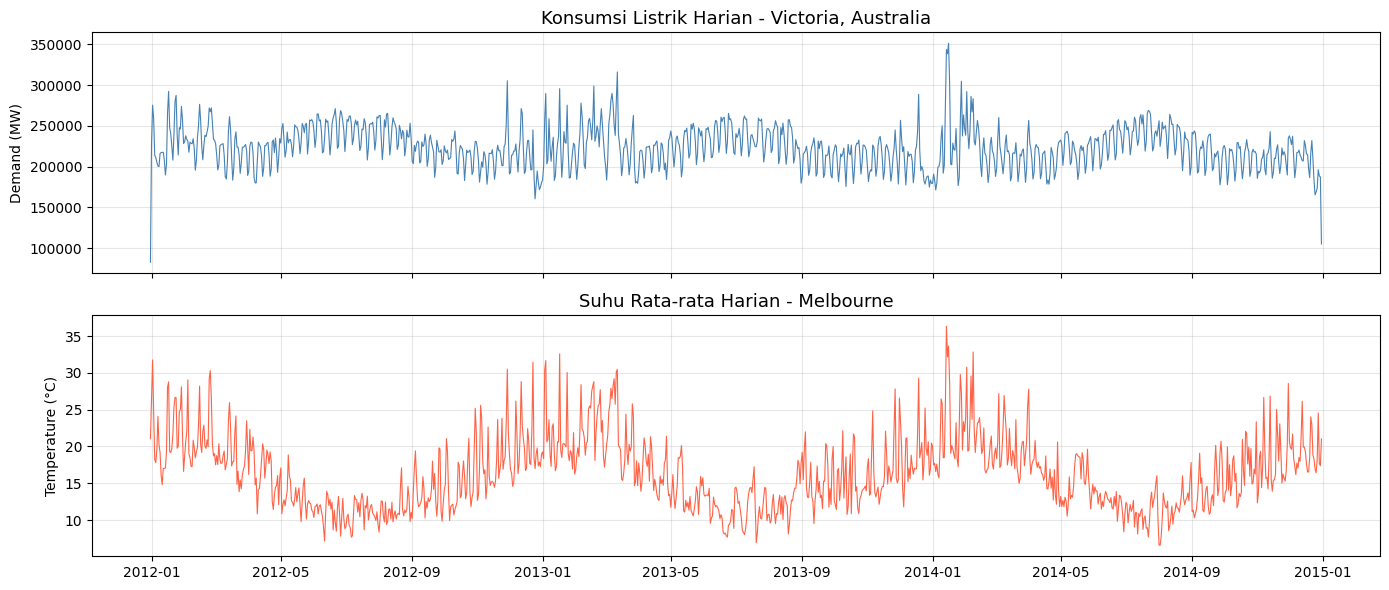

In [5]:
# Visualisasi data time series
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(data.index, data['Demand'], color='steelblue', linewidth=0.8)
axes[0].set_title('Konsumsi Listrik Harian - Victoria, Australia', fontsize=13)
axes[0].set_ylabel('Demand (MW)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(data.index, data['Temperature'], color='tomato', linewidth=0.8)
axes[1].set_title('Suhu Rata-rata Harian - Melbourne', fontsize=13)
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ❓ 3. Apa Itu Lag?

**Lag** adalah nilai dari **waktu sebelumnya** yang dijadikan sebagai fitur input untuk memprediksi nilai saat ini.

### Analogi Sederhana:
Bayangkan kamu ingin memprediksi konsumsi listrik hari ini (Senin). Untuk itu, kamu menggunakan data 7 hari ke belakang:

| Fitur | Arti |
|---|---|
| `lag_1` | Konsumsi listrik kemarin (Minggu) |
| `lag_2` | Konsumsi listrik 2 hari lalu (Sabtu) |
| `lag_3` | Konsumsi listrik 3 hari lalu (Jumat) |
| ... | ... |
| `lag_7` | Konsumsi listrik 7 hari lalu (Senin minggu lalu) |

### Kenapa lag diperlukan?
Model machine learning seperti LightGBM **tidak memahami urutan waktu secara otomatis**. Dengan membuat kolom lag, kita mengubah problem time series menjadi **problem regresi tabular biasa** yang bisa diproses model.

### Contoh bentuk data training setelah dibuat lag:

| lag_1 | lag_2 | lag_3 | lag_4 | lag_5 | lag_6 | lag_7 | Temperature | **y (target)** |
|---|---|---|---|---|---|---|---|---|
| 200693 | 205338 | 211066 | 213792 | 258955 | 275490 | 227778 | 24.09 | **216201** |
| 200061 | 200693 | 205338 | 211066 | 213792 | 258955 | 275490 | 20.22 | **200061** |

> **Ringkasan**: `lags = 7` berarti model menggunakan 7 nilai historis (1 minggu ke belakang) sebagai fitur input.

---
## 🤖 Membuat dan Melatih Forecaster

`ForecasterRecursive` adalah komponen utama dari skforecast. Cara kerjanya:
1. Mengambil model ML (di sini: LightGBM)
2. Secara otomatis membuat **lag features** dari time series
3. Melatih model menggunakan fitur-fitur tersebut
4. Saat prediksi, output dari prediksi sebelumnya dijadikan input (recursive/autoregressive)

Parameter yang digunakan:
- `regressor = LGBMRegressor(random_state=123)` → model yang digunakan
- `lags = 7` → gunakan 7 hari ke belakang sebagai fitur
- `y = data['Demand']` → target prediksi
- `exog = data['Temperature']` → fitur tambahan (eksogen)

In [6]:
# Buat dan latih forecaster
forecaster = ForecasterRecursive(
    regressor = LGBMRegressor(random_state=123, verbose=-1),
    lags = 7
)

forecaster.fit(
    y = data['Demand'],
    exog = data['Temperature']
)

print("✅ Forecaster berhasil dilatih!")
print(forecaster)

TypeError: ForecasterRecursive.__init__() got an unexpected keyword argument 'regressor'

In [ ]:
# Lihat bentuk matriks training yang dibuat skforecast secara otomatis
X_train, y_train = forecaster.create_train_X_y(
    y = data['Demand'],
    exog = data['Temperature']
)

print("=" * 60)
print("MATRIKS X_train (FITUR INPUT):")
print("=" * 60)
print(f"Shape: {X_train.shape}  ({X_train.shape[0]} baris, {X_train.shape[1]} kolom)")
print("\nKolom:", X_train.columns.tolist())
print("\n5 baris pertama:")
display(X_train.head())

print("\n" + "=" * 60)
print("y_train (TARGET OUTPUT):")
print("=" * 60)
print(y_train.head())

---
## 🧪 4. Proses Analisis Explainability

Setelah model dilatih, kita melakukan **4 tahap analisis explainability** untuk memahami:
- Fitur mana yang paling penting?
- Bagaimana masing-masing fitur mempengaruhi prediksi?

### Tahap Analisis:
1. **Feature Importance** — Pentingnya fitur berdasarkan model LightGBM
2. **SHAP Summary Plot** — Kontribusi setiap fitur terhadap prediksi
3. **SHAP Force Plot** — Penjelasan prediksi individual
4. **Partial Dependence Plot** — Hubungan marginal antara fitur dan target
5. **Permutation Importance** — Pentingnya fitur berdasarkan penurunan performa

### 📊 Tahap 1: Model-Specific Feature Importance

**Feature importance** mengukur seberapa besar kontribusi setiap fitur dalam membuat keputusan prediksi oleh model.

Untuk model **LightGBM (gradient boosting berbasis tree)**, feature importance dihitung berdasarkan:
- **Split count**: Berapa kali fitur digunakan untuk memisahkan data di tree
- **Gain**: Seberapa besar pengurangan error yang dihasilkan fitur tersebut

skforecast menyediakan method `get_feature_importances()` yang langsung mengakses atribut `feature_importances_` dari model internal.

In [ ]:
# Ambil feature importance dari forecaster
importance = forecaster.get_feature_importances()

print("Feature Importance:")
display(importance.sort_values('importance', ascending=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
importance_sorted = importance.sort_values('importance', ascending=True)
bars = ax.barh(importance_sorted['feature'], importance_sorted['importance'],
               color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — LightGBM\n(Jumlah split di decision tree)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, importance_sorted['importance']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
### 📊 Tahap 2: SHAP Values — Summary Plot

**SHAP (SHapley Additive exPlanations)** adalah metode yang berasal dari teori permainan kooperatif (cooperative game theory).

#### Cara kerja SHAP:
SHAP menghitung **kontribusi marginal** setiap fitur terhadap prediksi, dengan cara:
1. Mengevaluasi semua kemungkinan kombinasi fitur
2. Menghitung seberapa besar perubahan prediksi ketika fitur tersebut "dimasukkan" atau "dikeluarkan"
3. Nilai SHAP = rata-rata kontribusi marginal fitur tersebut

#### Kelebihan SHAP vs Feature Importance biasa:
- **Global** (seperti feature importance) — bisa dilihat secara keseluruhan
- **Lokal** — bisa menjelaskan prediksi untuk satu data point tertentu
- Memperlihatkan **arah pengaruh** (positif/negatif)

Untuk model berbasis tree (LightGBM, XGBoost, Random Forest), digunakan **TreeExplainer** yang sangat efisien.

#### Membaca SHAP Summary Plot:
- **Sumbu Y**: Daftar fitur
- **Sumbu X**: Nilai SHAP (positif = mendorong prediksi naik, negatif = mendorong prediksi turun)
- **Warna titik**: Nilai fitur (merah = tinggi, biru = rendah)

In [ ]:
# Buat SHAP TreeExplainer menggunakan regressor internal dari forecaster
explainer = shap.TreeExplainer(forecaster.regressor)

# Hitung SHAP values untuk seluruh data training
shap_values = explainer.shap_values(X_train)

print(f"Shape SHAP values: {shap_values.shape}")
print(f"Shape X_train: {X_train.shape}")
print("\nSetiap baris = satu observasi, setiap kolom = nilai SHAP untuk satu fitur")

In [ ]:
# SHAP Summary Plot - Bar chart (global importance)
print("📊 SHAP Summary Plot (Bar) — Rata-rata |SHAP value| per fitur")
shap.summary_plot(shap_values, X_train, plot_type="bar", show=True)

In [ ]:
# SHAP Summary Plot - Dot/Beeswarm (distribusi pengaruh fitur)
print("📊 SHAP Beeswarm Plot — Distribusi nilai SHAP dengan warna nilai fitur")
shap.summary_plot(shap_values, X_train, show=True)

---
### 📊 Tahap 3: SHAP Force Plot — Penjelasan Prediksi Individual

**Force Plot** adalah visualisasi lokal yang menunjukkan **bagaimana setiap fitur berkontribusi pada satu prediksi tertentu**.

Cara membaca Force Plot:
- **Base value**: Rata-rata prediksi model dari seluruh data
- **Output value**: Prediksi untuk observasi ini
- **Panah merah**: Fitur yang mendorong prediksi **naik** dari base value
- **Panah biru**: Fitur yang mendorong prediksi **turun** dari base value
- **Panjang panah**: Besarnya pengaruh fitur tersebut

In [ ]:
# Force plot untuk observasi pertama dalam data training
print("📊 Force Plot — Observasi pertama (index 0)")
print(f"Tanggal: {X_train.index[0].date()}")
print(f"Prediksi: {explainer.expected_value + shap_values[0,:].sum():.0f} MW")
print("\nNilai fitur:")
display(X_train.iloc[[0]])

# Force plot interaktif
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :]
)

In [ ]:
# Force plot untuk 200 observasi pertama (stacked/multi-sample view)
print("📊 Multi-sample Force Plot — 200 observasi pertama")
shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

---
### 📊 Tahap 4: SHAP Dependence Plot

**SHAP Dependence Plot** menunjukkan hubungan antara **nilai satu fitur** dengan **nilai SHAP-nya** (kontribusinya terhadap prediksi).

- **Sumbu X**: Nilai fitur yang dipilih (misal: Temperature)
- **Sumbu Y**: Nilai SHAP fitur tersebut
- **Warna titik**: Nilai fitur lain yang berinteraksi (dipilih otomatis oleh SHAP)

Plot ini berguna untuk melihat:
- Apakah hubungan fitur-target bersifat **linear atau non-linear**?
- Apakah ada **interaksi** dengan fitur lain?
- Di kisaran nilai berapa fitur paling berpengaruh?

In [ ]:
# SHAP Dependence Plot untuk Temperature
print("📊 SHAP Dependence Plot — Temperature vs SHAP Value")
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)
ax.set_title("Dependence Plot: Temperature\n(Warna = fitur lain yang paling berinteraksi)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# SHAP Dependence Plot untuk lag_1
print("📊 SHAP Dependence Plot — lag_1 vs SHAP Value")
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot("lag_1", shap_values, X_train, ax=ax)
ax.set_title("Dependence Plot: lag_1 (Demand kemarin)\n(Warna = fitur lain yang paling berinteraksi)",
             fontsize=12)
plt.tight_layout()
plt.show()

---
### 📊 Tahap 5: Permutation Feature Importance

**Permutation Importance** adalah metode model-agnostik untuk mengukur pentingnya fitur.

#### Cara kerjanya:
1. Latih model dan catat skor error baseline (misal: MAE atau RMSE)
2. Untuk setiap fitur, **acak (shuffle) nilai fitur tersebut** secara acak
3. Hitung skor error setelah pengacakan
4. **Selisih error** = seberapa penting fitur itu (semakin besar penurunan error, semakin penting)

#### Perbedaan dengan Feature Importance bawaan model:
| | Feature Importance | Permutation Importance |
|---|---|---|
| Basis | Struktur internal tree | Perubahan performa model |
| Model-agnostik | ❌ | ✅ |
| Mempertimbangkan interaksi | Terbatas | ✅ |
| Rentan bias fitur banyak kategori | Ya | Tidak |

#### Rumus:
$$I_i = \text{Error}_{\text{permuted}(i)} - \text{Error}_{\text{original}}$$

In [ ]:
# Hitung Permutation Importance menggunakan sklearn
result = permutation_importance(
    estimator = forecaster.regressor,  # model internal forecaster
    X = X_train,
    y = y_train,
    n_repeats = 5,         # diulang 5 kali untuk mendapat estimasi stabil
    random_state = 123,
    n_jobs = -1
)

# Buat dataframe hasil
perm_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Permutation Importance:")
display(perm_importance_df)

In [ ]:
# Visualisasi Permutation Importance dengan error bar
fig, ax = plt.subplots(figsize=(8, 5))

sorted_df = perm_importance_df.sort_values('importance_mean', ascending=True)
ax.barh(
    sorted_df['feature'],
    sorted_df['importance_mean'],
    xerr=sorted_df['importance_std'],
    color='darkorange',
    alpha=0.8,
    error_kw=dict(ecolor='black', capsize=4)
)

ax.set_title('Permutation Feature Importance\n(Mean ± Std dari 5 pengulangan)', fontsize=13)
ax.set_xlabel('Peningkatan Error saat fitur diacak (R²)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
### 📊 Tahap 6: Partial Dependence Plot (PDP)

**Partial Dependence Plot (PDP)** menunjukkan hubungan **marginal** antara satu atau dua fitur dengan target prediksi, dengan cara **memarginalisasi (merata-ratakan) pengaruh semua fitur lainnya**.

#### Cara membaca PDP:
- **Sumbu X**: Nilai fitur yang diamati
- **Sumbu Y**: Rata-rata prediksi model saat nilai fitur tersebut diset ke nilai itu
- Berguna untuk melihat **tren hubungan** fitur-target secara keseluruhan

#### Perbedaan PDP vs SHAP Dependence Plot:
| | PDP | SHAP Dependence Plot |
|---|---|---|
| Menampilkan observasi | ❌ (hanya rata-rata) | ✅ (scatter) |
| Memperhitungkan interaksi | Terbatas | ✅ (via warna) |
| Interpretasi | Lebih mudah | Lebih informatif |

skforecast kompatibel dengan fungsi `PartialDependenceDisplay` dari scikit-learn.

In [ ]:
# Partial Dependence Plot untuk Temperature dan lag_1
print("📊 Partial Dependence Plot — Temperature dan lag_1")

fig, ax = plt.subplots(figsize=(12, 5))

pdp_display = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X = X_train,
    features = ["Temperature", "lag_1"],
    kind = 'both',  # 'average' untuk PDP biasa, 'both' untuk PDP + Individual (ICE)
    ax = ax,
    grid_resolution = 50
)

ax.set_title("Partial Dependence Plot\n(Garis tebal = rata-rata, garis tipis = individual predictions)",
             fontsize=12)
plt.tight_layout()
plt.show()

---
## ✅ Ringkasan Temuan Analisis

### 1. Fitur Paling Penting
Berdasarkan semua metode explainability, ditemukan bahwa:
- **Temperature** → Fitur paling penting. Suhu sangat mempengaruhi konsumsi listrik (AC saat panas, pemanas saat dingin)
- **lag_1** → Konsumsi kemarin sangat relevan (ada inertia/momentum dalam konsumsi listrik)
- **lag_7** → Konsumsi minggu lalu juga penting (pola mingguan: hari kerja vs weekend)

### 2. Hubungan Fitur-Target
- **Temperature**: Hubungan **non-linear berbentuk U** — konsumsi listrik tinggi saat suhu sangat rendah (pemanas) maupun sangat tinggi (AC)
- **lag_1 s.d. lag_7**: Hubungan **positif** — konsumsi hari sebelumnya yang tinggi cenderung diikuti konsumsi tinggi pula

### 3. Insight dari SHAP Force Plot
- Untuk satu prediksi tertentu, bisa diidentifikasi secara tepat fitur mana yang "mendorong naik" dan mana yang "mendorong turun" prediksi dari nilai baseline

---

## 📚 Kesimpulan Tentang Explainability

| Metode | Scope | Kelebihan |
|---|---|---|
| Feature Importance | Global | Cepat, bawaan model |
| Permutation Importance | Global | Model-agnostik, reliable |
| SHAP Summary Plot | Global | Menampilkan distribusi dan arah pengaruh |
| SHAP Force Plot | **Lokal** | Menjelaskan prediksi individual |
| SHAP Dependence Plot | Global | Menampilkan non-linearitas dan interaksi |
| Partial Dependence Plot | Global | Hubungan marginal fitur-target |

> **Explainability bukan hanya nilai akademis** — dalam aplikasi nyata seperti sistem energi, kesehatan, atau keuangan, memahami *mengapa* model membuat prediksi tertentu adalah krusial untuk kepercayaan dan pengambilan keputusan.
